# YB 2조 미니 프로젝트(1) 조별 과제
- 관련 사이트: https://dacon.io/competitions/open/235536/data
- 과제: 지금까지 배운 파이썬 기초와 시각화 코드를 통해 유의미한 결과 출력하고, 10개 이상의 그래프 그리기 (데이터 전처리는 예시 참고)
- 조건: 변수 2개 이상 연결한 결과값 포함

**1. 라이브러리 및 데이터 불러오기**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

pd.options.mode.chained_assignment = None  # default='warn'

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

movies = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/movies_train.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**2. 탐색적 자료분석(EDA)**

(1) 데이터 설명
- 2010년대 한국에서 개봉한 한국영화 600개에 대한 감독, 이름, 상영등급, 관객수 등의 정보가
담긴 데이터

(2) 변수 살펴보기
- title : 영화의 제목
- distributor : 배급사
- genre : 장르
- release_time : 개봉일
- time : 상영시간(분)
- screening_rat : 상영등급
- director : 감독이름
- dir_prev_bfnum : 해당 감독이 이 영화를 만들기 전 제작에 참여한 영화에서의 평균 관객수(단, 관객수가 알려지지 않은 영화 제외)
- dir_prev_num : 해당 감독이 이 영화를 만들기 전 제작에 참여한 영화의 개수(단, 관객수가 알려지지 않은 영화 제외)
- num_staff : 스텝수
- num_actor : 주연배우수
- box_off_num : 관객수

(3) 데이터 요약

In [ ]:
movies.head()

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,NaN,0,91,2,23398
1,내부자들,(주)쇼박스,느와르,2015-11-19,130,청소년 관람불가,우민호,1161602.5,2,387,3,7072501
2,은밀하게 위대하게,(주)쇼박스,액션,2013-06-05,123,15세 관람가,장철수,220775.2,4,343,4,6959083
3,나는 공무원이다,(주)NEW,코미디,2012-07-12,101,전체 관람가,구자홍,23894.0,2,20,6,217866
4,불량남녀,쇼박스(주)미디어플렉스,코미디,2010-11-04,108,15세 관람가,신근호,1.0,1,251,2,483387


In [ ]:
movies.tail()

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
595,해무,(주)NEW,드라마,2014-08-13,111,청소년 관람불가,심성보,3833.0,1,510,7,1475091
596,파파로티,(주)쇼박스,드라마,2013-03-14,127,15세 관람가,윤종찬,496061.0,1,286,6,1716438
597,살인의 강,(주)마운틴픽쳐스,공포,2010-09-30,99,청소년 관람불가,김대현,NaN,0,123,4,2475
598,악의 연대기,CJ 엔터테인먼트,느와르,2015-05-14,102,15세 관람가,백운학,NaN,0,431,4,2192525
599,베를린,CJ 엔터테인먼트,액션,2013-01-30,120,15세 관람가,류승완,NaN,0,363,5,7166532


In [ ]:
print(movies.shape)

(600, 12)


In [ ]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           600 non-null    object 
 1   distributor     600 non-null    object 
 2   genre           600 non-null    object 
 3   release_time    600 non-null    object 
 4   time            600 non-null    int64  
 5   screening_rat   600 non-null    object 
 6   director        600 non-null    object 
 7   dir_prev_bfnum  270 non-null    float64
 8   dir_prev_num    600 non-null    int64  
 9   num_staff       600 non-null    int64  
 10  num_actor       600 non-null    int64  
 11  box_off_num     600 non-null    int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 56.4+ KB


- 12개의 변수와 총 600개의 데이터 존재함을 확인

(4) 결측치 확인 및 데이터 전처리

In [ ]:
movies.isna().sum()

,0
title,0
distributor,0
genre,0
release_time,0
time,0
screening_rat,0
director,0
dir_prev_bfnum,330
dir_prev_num,0
num_staff,0


In [ ]:
movies[movies['dir_prev_bfnum'].isna()].head()

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,NaN,0,91,2,23398
6,길위에서,백두대간,다큐멘터리,2013-05-23,104,전체 관람가,이창재,NaN,0,32,5,53526
8,"1789, 바스티유의 연인들",유니버설픽쳐스인터내셔널코리아,뮤지컬,2014-09-18,129,전체 관람가,정성복,NaN,0,3,5,4778
9,청춘그루브,(주)두타연,드라마,2012-03-15,94,15세 관람가,변성현,NaN,0,138,3,868
10,AV 아이돌,(주) 케이알씨지,멜로/로맨스,2015-07-27,89,청소년 관람불가,조조 히데오,NaN,0,0,4,745


- 변수 'dir_prev_bfnun'에 330개의 결측치가 존재함을 확인
- 결측치는 NaN으로 저장되어 있음을 확인

- 해당 변수에 결측치가 존재함은 감독의 이전 작품이 존재하지 않음을 의미가히 때문에, NaN을 0으로 데이터 전처리 진행

In [ ]:
movies['dir_prev_bfnum'].fillna(0, inplace=True)

/tmp/ipykernel_21092/3577738027.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movies['dir_prev_bfnum'].fillna(0, inplace=True)


In [ ]:
movies[movies['dir_prev_bfnum'].isna()].head()  #0으로 제대로 변경되었는지 확인

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num


(5) 새로운 변수 추가 및 생성
: 데이터 분석 및 시각화를 위해 아래와 같은 변수를 추가 및 생성하고자 함

- is_restricted : 청불 여부
- release_month : 개봉 월
- dir_total_audience : 감독별 총 관객수
- genre_total_audience : 장르별 총 관객수
- time_category : 상영시간 구간( - 80, 80 - 120, 120 - )
- dir_performance_ratio : 감독 성과(이번 영화의 관객수 / 이전 영화들의 평균 관객수)
- total_manpower : 총 인력(스텝 수 + 주연배우 수)

In [ ]:
# 청불 여부
def check_restricted(rating):
    if rating == '청소년 관람불가':
        return '청불'
    else :
        return '안 청불'

movies['is_restricted'] = movies['screening_rat'].apply(check_restricted)

movies['is_restricted'].head()

,is_restricted
0,청불
1,청불
2,안 청불
3,안 청불
4,안 청불


In [ ]:
# 개봉 월
movies['release_time'] = pd.to_datetime(movies['release_time'])
movies['release_month'] = movies['release_time'].dt.month

movies['release_month'].head()

,release_month
0,11
1,11
2,6
3,7
4,11


In [ ]:
# 감독별 총 관객수
movies['dir_total_audience'] = movies.groupby('director')['box_off_num'].transform('sum')

movies['dir_total_audience'].head()

,dir_total_audience
0,23398
1,11480550
2,6959083
3,217866
4,483387


In [ ]:
# 장르별 총 관객수
movies['genre_total_audience'] = movies.groupby('genre')['box_off_num'].transform('sum')

movies['genre_total_audience'].head()

,genre_total_audience
0,61711274
1,61119768
2,61711274
3,63277442
4,63277442


In [ ]:
# 상영시간 구간
bins = [0, 80, 120, np.inf] # 0~80, 80~120, 120~무한대
labels = ['~80', '80~120', '120~']
movies['time_category'] = pd.cut(movies['time'], bins=bins, labels=labels)

movies['time_category'].head()

,time_category
0,80~120
1,120~
2,120~
3,80~120
4,80~120


In [ ]:
# 감독 성과
movies['dir_performance_ratio'] = movies['box_off_num'] / movies['dir_prev_bfnum']

movies['dir_performance_ratio'].head()

,dir_performance_ratio
0,inf
1,6.1
2,31.5
3,9.1
4,483387.0


In [ ]:
# 총 인력
movies['total_manpower'] = movies['num_staff'] + movies['num_actor']

movies['total_manpower'].head()

,total_manpower
0,93
1,390
2,347
3,26
4,253


(6) 데이터의 요약통계량 확인

In [ ]:
pd.options.display.float_format = '{:.1f}'.format

In [ ]:
movies.describe()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


,release_time,time,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num,release_month,dir_total_audience,genre_total_audience,dir_performance_ratio,total_manpower
count,600,600.0,600.0,600.0,600.0,600.0,600.0,600.0,600.0,600.0,600.0,600.0
mean,2013-04-16 10:12:00,100.9,472699.3,0.9,151.1,3.7,708181.8,7.0,1117359.1,70068962.6,inf,154.8
min,2010-01-02 00:00:00,45.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,33135.0,0.0,0.0
25%,2011-10-11 06:00:00,89.0,0.0,0.0,17.0,2.0,1297.2,4.0,2064.0,23248494.0,1.0,20.0
50%,2013-07-17 12:00:00,100.0,0.0,0.0,82.5,3.0,12591.0,7.0,23140.5,61711274.0,NaN,86.0
75%,2014-10-16 00:00:00,114.0,376141.6,2.0,264.0,4.0,479886.8,10.0,818705.8,138277444.0,NaN,266.5
max,2015-12-31 00:00:00,180.0,17615314.0,5.0,869.0,25.0,14262766.0,12.0,25690504.0,138277444.0,inf,873.0
std,NaN,18.1,1309474.3,1.2,165.7,2.4,1828005.9,3.4,2819281.4,55180312.8,NaN,165.9


**3. 데이터 분석 및 시각화**

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

plt.rc('font', family='NanumBarunGothic')  #matplotlib 한글 깨짐 방지

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

(1) 흥행의 기본 조건

**# 장르 - 관객수 : 어떤 장르가 가장 대중적인가?**

In [ ]:
# 장르별 평균 관객수 수치 확인
movies[['genre', 'box_off_num']].groupby('genre').mean().sort_values('box_off_num', ascending=False)

,box_off_num
genre,
느와르,2263695.1
액션,2203974.1
SF,1788345.7
코미디,1193914.0
드라마,625689.8
공포,590832.5
미스터리,527548.2
멜로/로맨스,425968.0
애니메이션,181926.7


<Axes: title={'center': '장르별 평균 관객수'}, xlabel='genre'>

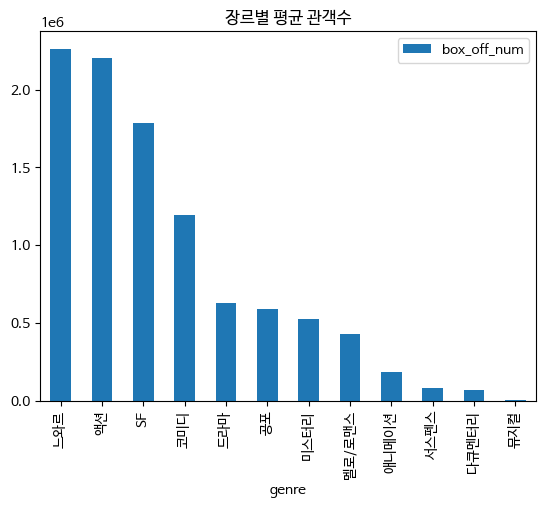

In [ ]:
# 장르별 평균 관객수 시각화 (바 차트)
movies[['genre', 'box_off_num']].groupby('genre').mean().sort_values('box_off_num', ascending=False).plot(kind='bar', title='장르별 평균 관객수')

- 느와르, 액션, SF 장르 순으로 관객수가 많음

In [ ]:
movies['genre'].value_counts()

,count
genre,
드라마,221
다큐멘터리,93
멜로/로맨스,78
코미디,53
공포,42
액션,28
느와르,27
애니메이션,21
미스터리,17


- 장르별 영화 개수와 장르별 관객수는 비례하지 않음
- 느와르, 액션, SF 등이 대중적이며, 흥행하기 좋은 영화임

**# 청불 유무 - 관객수 : 관람 연령 제한이 흥행의 허들이 되는가?**

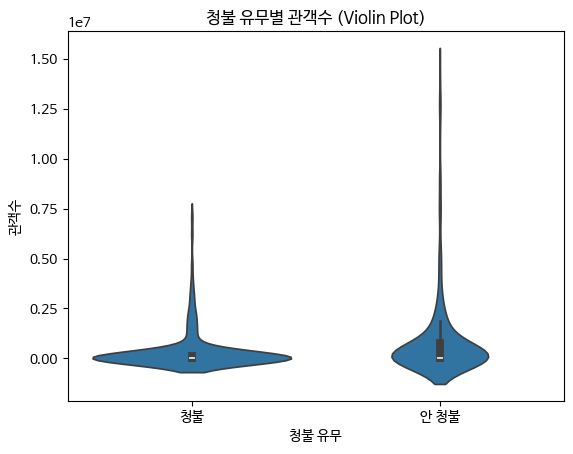

In [ ]:
sns.violinplot(x='is_restricted', y='box_off_num', data=movies)

plt.title('청불 유무별 관객수 (Violin Plot)')
plt.ylabel('관객수')
plt.xlabel('청불 유무')
plt.show()

- 이상치들로 그래프가 위로 길게 늘어나서 데이터를 제대로 분석하기 어려움

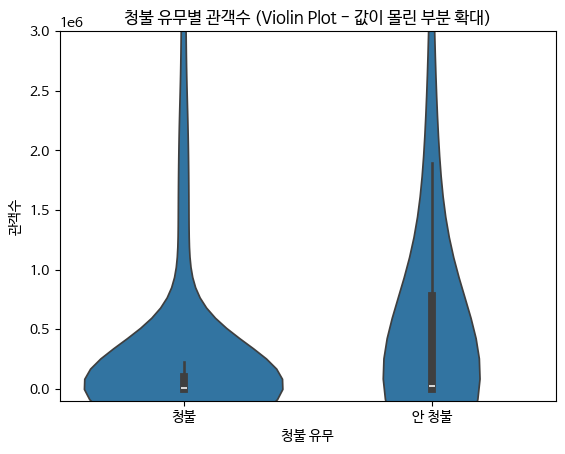

In [ ]:
sns.violinplot(x='is_restricted', y='box_off_num', data=movies)

plt.title('청불 유무별 관객수 (Violin Plot - 값이 몰린 부분 확대)')
plt.ylabel('관객수')
plt.xlabel('청불 유무')

plt.ylim(-100000, 3000000)

plt.show()

- 청불 영화는 0 근처에 값이 매우 몰려있음. 즉, 청불 영화의 대다수는 관객을 거의 모으지 못하고 있음
- 청불이 아닌 영화는 상대적으로 위아래로 길고 넓게 퍼져있음. 꽤 고르게 관객수가 분포하고 있음. 중앙값(하얀 선) 또한 청불보다 위쪽에 찍혀있어, 평균적으로 성적이 더 좋음을 의미함
- 청소년 관람불가라는 연령 제한은 흥행의 허들이 됨

**# 배급사 - 관객수 : 다작의 배급사 이름값(마케팅 파워)이 흥행을 보장하는가?**

In [ ]:
# 상위 10개 배급사 필터링
top10_distributors = movies['distributor'].value_counts().head(10).index
top10_movies = movies[movies['distributor'].isin(top10_distributors)]

top10_movies.head()

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num,is_restricted,release_month,dir_total_audience,genre_total_audience,time_category,dir_performance_ratio,total_manpower
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,0.0,0,91,2,23398,청불,11,23398,61711274,80~120,inf,93
1,내부자들,(주)쇼박스,느와르,2015-11-19,130,청소년 관람불가,우민호,1161602.5,2,387,3,7072501,청불,11,11480550,61119768,120~,6.1,390
2,은밀하게 위대하게,(주)쇼박스,액션,2013-06-05,123,15세 관람가,장철수,220775.2,4,343,4,6959083,안 청불,6,6959083,61711274,120~,31.5,347
3,나는 공무원이다,(주)NEW,코미디,2012-07-12,101,전체 관람가,구자홍,23894.0,2,20,6,217866,안 청불,7,217866,63277442,80~120,9.1,26
5,강철대오 : 구국의 철가방,롯데엔터테인먼트,코미디,2012-10-25,113,15세 관람가,육상효,837969.0,2,262,4,233211,안 청불,10,1205642,63277442,80~120,0.3,266


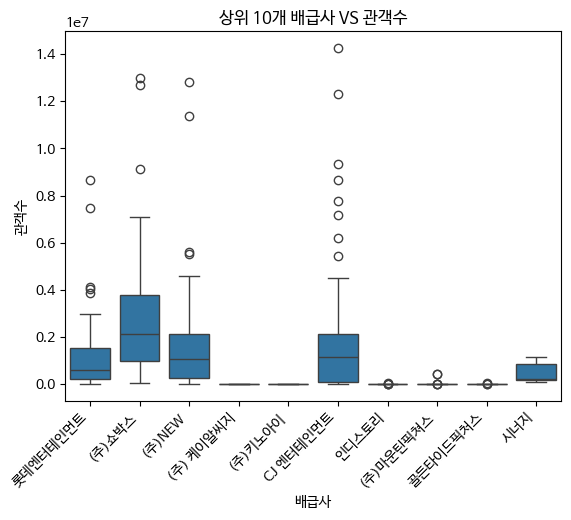

In [ ]:
sns.boxplot(x='distributor', y='box_off_num', data=top10_movies)

plt.title('상위 10개 배급사 VS 관객수')
plt.ylabel('관객수')
plt.xlabel('배급사')
plt.xticks(rotation=45, ha='right') #45도 글씨를 기울이고, 오른쪽 정렬
plt.show()

- 상위 10개 배급사 분석 결과, 배급사 간의 양극화가 매우 심함. CJ, 쇼박스, 롯데엔터테이먼트, NEW가 영화계의 상위권을 독식하고 있음
- 즉, 다작의 배급사가 관객수를 보장하는 것은 아님

In [ ]:
# 개봉월 - 장르 : 특정 기간(방학, 휴일 등)에 특정 장르가 집중되는 계절성이 있는가?

(2) 산업의 규모와 자본력

In [ ]:
# 상영시간 구간 – 상영등급: 상영 등급별로 영화 길이(자본력)에 차이가 있는가?

In [ ]:
# 배급사 - 스텝수 : 대형 배급사일수록 자본력이 커서 투입하는 스텝이 많은가?

In [ ]:
# 배급사 - 장르 : 배급사별로 추구하는 장르가 존재하는가?

In [ ]:
# 배급사 - 청불 유무 : 배급사별로 타겟팅하고자 하는 연령대 전략이 다른가?

In [ ]:
# 배급사 - 감독(이전 작품이 3개 이상인 or ~ 조정하면서): 배급사별로 선호하는 감독이 존재하는가?

(3) 감독의 역량과 인력 운용의 효율성

In [ ]:
# 감독 - 총 인력 : 감독별 추구하는 현장 규모가 존재하는가?

In [ ]:
# 총 인력 - 감독 성과 : 투입된 전체 인력 대비, 감독 본인의 평균 관객수보다 이번 영화에서 얼마나 더 뛰어난 성과를 냈을까?

In [ ]:
# 총 인력 - 관객수 - 감독(총 관객이 꽤 많은) : 뭐라고 쓰지?